In [1]:
import cupy as cp
import numpy as np

In [2]:
backward_solve_SDE = cp.ElementwiseKernel(
    'float32 k, float32 C',
    'float32 x_next',
    r'''
    const double pi = 3.141592653589793238462643383279502884;
    const double a  = 2.0 * pi;

    double kk = (double)k;
    double cc = (double)C;
    double x;

    if (fabs(kk) < 1.0e-100) {
        x = cc;
    } else {
        const double b = pi;   // drift center

        const double A = 1.0 + kk;
        const double B = -(cc + a + kk * (a + b));
        const double G = a * cc + a * b * kk - 2.0 * kk;
        const double D = a * kk;

        const double p = (3.0 * A * G - B * B) / (3.0 * A * A);
        const double q = (2.0 * B * B * B - 9.0 * A * B * G + 27.0 * A * A * D)
                       / (27.0 * A * A * A);

        const double Delta = 0.25 * q * q + (p * p * p) / 27.0;
        const double shift = -B / (3.0 * A);

        if (Delta >= 0.0) {
            const double s1 = rcbrt_double(-0.5 * q + sqrt(Delta));
            const double s2 = rcbrt_double(-0.5 * q - sqrt(Delta));
            x = s1 + s2 + shift;
        } else {
            const double rho = 2.0 * sqrt(-p / 3.0);
            double arg = (-0.5 * q) / sqrt(-((p / 3.0) * (p / 3.0) * (p / 3.0)));

            // important for numerical safety
            if (arg > 1.0) arg = 1.0;
            if (arg < -1.0) arg = -1.0;

            const double phi = acos(arg);

            const double r0 = rho * cos(phi / 3.0) + shift;
            const double r1 = rho * cos((phi + 2.0 * pi) / 3.0) + shift;
            const double r2 = rho * cos((phi + 4.0 * pi) / 3.0) + shift;

            double best = 0.0;
            double fbest = 0.0;
            bool found = false;

            if (r0 > 0.0 && r0 < a) {
                double fr = fabs(Fval(r0, kk, cc, a, pi));
                best = r0;
                fbest = fr;
                found = true;
            }
            if (r1 > 0.0 && r1 < a) {
                double fr = fabs(Fval(r1, kk, cc, a, pi));
                if (!found || fr < fbest) {
                    best = r1;
                    fbest = fr;
                    found = true;
                }
            }
            if (r2 > 0.0 && r2 < a) {
                double fr = fabs(Fval(r2, kk, cc, a, pi));
                if (!found || fr < fbest) {
                    best = r2;
                    fbest = fr;
                    found = true;
                }
            }

            if (found) {
                x = best;
            } else {
                x = nan("");
            }
        }
    }

    x_next = (float)x;
    ''',
    'backward_solve_SDE',
    preamble=r'''
    __device__ inline double rcbrt_double(double z) {
        return (z >= 0.0) ? cbrt(z) : -cbrt(-z);
    }

    __device__ inline double Fval(double x, double k, double C, double a, double pi) {
        return x - C - k * (pi - x + 1.0 / x + 1.0 / (x - a));
    }
    '''
)

In [3]:
import numpy as np
import cupy as cp
import matplotlib.pyplot as plt

# -------------------------------------------------
# Define your drift pieces on GPU
# -------------------------------------------------
def f(r):
    return cp.pi - r

def wall_rep(r):
    return 1.0 / r + 1.0 / (r - 2.0 * cp.pi)

# -------------------------------------------------
# Logarithmic step grid: 1, 5, 10, 50, 100, ...
# -------------------------------------------------
def make_step_grid(max_steps=10**6):
    vals = [1]
    k = 0
    while True:
        a = 5 * (10**k)
        b = 10 * (10**k)
        if a <= max_steps:
            vals.append(a)
        if b <= max_steps:
            vals.append(b)
        if b >= max_steps:
            break
        k += 1
    return sorted(set(vals))

# -------------------------------------------------
# Maximum parallel paths that fit on GPU
# Only depends on per-path state, not on n_steps
# -------------------------------------------------
def max_parallel_paths(safety=0.85, dtype=cp.float32):
    free_bytes, total_bytes = cp.cuda.Device().mem_info
    usable_bytes = int(free_bytes * safety)

    # Per path we keep roughly:
    # x                : float
    # noise            : float
    # x_new            : float
    # active mask      : bool
    # escaped mask/tmp : bool
    #
    # Use a conservative estimate
    itemsize = cp.dtype(dtype).itemsize
    bytes_per_path = 3 * itemsize + 2 * 1 + 16

    n_paths = usable_bytes // bytes_per_path
    return max(1, int(n_paths))

# -------------------------------------------------
# Simulate one batch on GPU without storing paths
# Returns number of escaped paths in this batch
# -------------------------------------------------
def escaped_in_one_batch(n_paths, n_steps, T=100.0, mu=1, epsilon=1, dtype=cp.float32):
    dt = T / n_steps
    sqrt_dt = np.sqrt(dt)
    sqrt_epsilon = np.sqrt(epsilon)
    k = 2.0 * mu * dt
    x = cp.full(n_paths, cp.pi, dtype=dtype)
    active = cp.ones(n_paths, dtype=cp.bool_)

    n_escaped = 0

    lower = dtype(0.0)
    upper = dtype(2.0 * np.pi)

    for _ in range(n_steps):
        n_active = int(active.sum().item())
        if n_active == 0:
            break

        idx = cp.where(active)[0]
        x_active = x[idx]

        C = x_active+2*sqrt_dt*sqrt_epsilon*cp.random.standard_normal(n_active, dtype=dtype)

        x_new = backward_solve_SDE(k, C)

        escaped_now = cp.isnan(x_new) | (x_new <= lower) | (x_new >= upper)

        n_escaped += int(escaped_now.sum().item())
        survivors = ~escaped_now
        x[idx[survivors]] = x_new[survivors]
        active[idx[escaped_now]] = False

    return n_escaped

# -------------------------------------------------
# Run total_paths by repeatedly using the largest
# batch size that fits on GPU
# -------------------------------------------------
def escape_percentage_for_steps(total_paths, n_steps, T=100.0, mu=0.01, epsilon=0.01,
                                dtype=cp.float32, safety=0.85):
    batch_size = max_parallel_paths(safety=safety, dtype=dtype)

    done = 0
    total_escaped = 0

    while done < total_paths:
        current_batch = min(batch_size, total_paths - done)

        escaped_batch = escaped_in_one_batch(
            n_paths=current_batch,
            n_steps=n_steps,
            T=T,
            mu=mu,
            epsilon=epsilon,
            dtype=dtype
        )

        total_escaped += escaped_batch
        done += current_batch

        cp.get_default_memory_pool().free_all_blocks()

        print(f"n_steps={n_steps}, done={done}/{total_paths}, escaped={total_escaped}")

    return 100.0 * total_escaped / total_paths, batch_size


n_steps=1, done=10000000/10000000, escaped=0
Finished n_steps=1, escape percentage=0.000000%, batch_size=209571894
n_steps=5, done=10000000/10000000, escaped=0
Finished n_steps=5, escape percentage=0.000000%, batch_size=209453056
n_steps=10, done=10000000/10000000, escaped=0
Finished n_steps=10, escape percentage=0.000000%, batch_size=209453056
n_steps=50, done=10000000/10000000, escaped=0
Finished n_steps=50, escape percentage=0.000000%, batch_size=209453056
n_steps=100, done=10000000/10000000, escaped=0
Finished n_steps=100, escape percentage=0.000000%, batch_size=209453056
n_steps=500, done=10000000/10000000, escaped=0
Finished n_steps=500, escape percentage=0.000000%, batch_size=209453056
n_steps=1000, done=10000000/10000000, escaped=0
Finished n_steps=1000, escape percentage=0.000000%, batch_size=209453056
n_steps=5000, done=10000000/10000000, escaped=0
Finished n_steps=5000, escape percentage=0.000000%, batch_size=209453056
n_steps=10000, done=10000000/10000000, escaped=0
Finishe

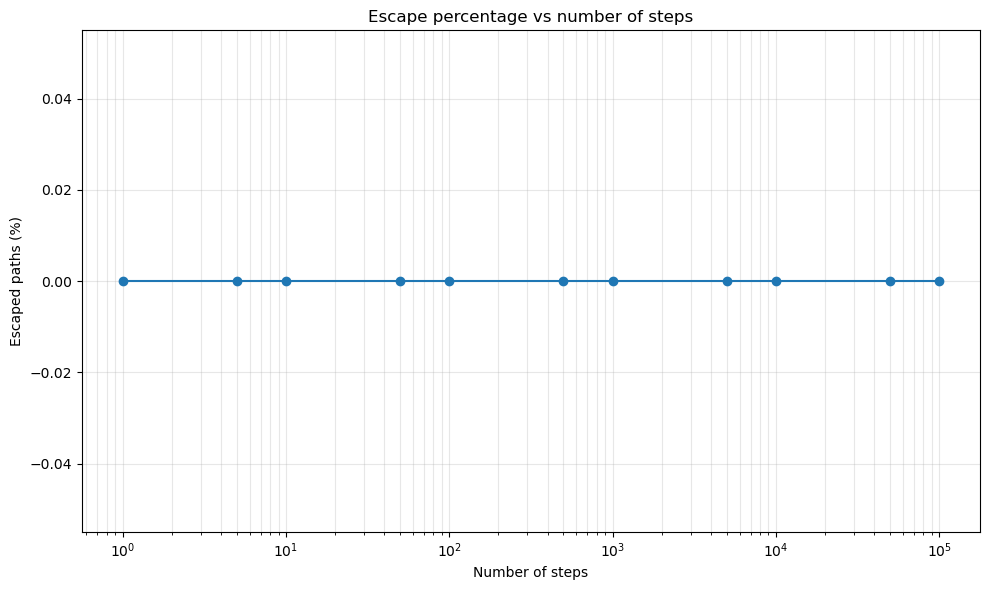

In [4]:

# -------------------------------------------------
# Sweep over step sizes
# -------------------------------------------------
total_paths = 10**7
step_grid = make_step_grid(10**5)

escape_percentages = []
batch_sizes = []

for n_steps in step_grid:
    pct, batch_size = escape_percentage_for_steps(
        total_paths=total_paths,
        n_steps=n_steps,
        T=100.0,
        mu=0.01,
        epsilon=0.01,
        dtype=cp.float32,   # float32 gives more parallel paths
        safety=0.85
    )
    escape_percentages.append(pct)
    batch_sizes.append(batch_size)

    print(f"Finished n_steps={n_steps}, escape percentage={pct:.6f}%, batch_size={batch_size}")

# -------------------------------------------------
# Plot
# -------------------------------------------------
plt.figure(figsize=(10, 6))
plt.semilogx(step_grid, escape_percentages, marker="o")
plt.xlabel("Number of steps")
plt.ylabel("Escaped paths (%)")
plt.title("Escape percentage vs number of steps")
plt.grid(True, which="both", alpha=0.3)
plt.tight_layout()
plt.show()